In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df=pd.read_csv("../00_data/split_data/eda.csv")
df

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,BalanceGross_num,NAICS_sector,IsFranchise,NewExist_f,UrbanRural_f,PaidInFull,SBA_Portion,RevLineCr_f,LowDoc_f,GFC_Period
0,1285015002,Monroe Grill Corporation,HERNDON,VA,20170,BANK OF AMERICA NATL ASSOC,NC,722211,28-Apr-05,2005,...,0,72,No,New,Urban,1,0.50,Yes,No,Pre-GFC
1,7453294006,"CUYAHOGA BRIDGE & ROAD, INC.",MEDINA,OH,44256,HOME SAVINGS & LOAN CO OF YOU,OH,237310,19-May-04,2004,...,0,23,No,New,Urban,1,0.75,No,No,Pre-GFC
2,3069936008,ANY OCCASION LIMOUSINE,LOXLEY,AL,36551,COMPASS BANK,AL,485320,16-Nov-07,2008,...,0,48,No,Existing,Rural,1,0.50,Yes,No,GFC
3,5148084007,MADISON FLORAL INC,ARLINGTON,MA,2174,BANK OF AMERICA NATL ASSOC,RI,453110,9-Jan-02,2002,...,0,45,No,Existing,Urban,1,0.50,Yes,No,Pre-GFC
4,2452396010,AMERICAN GENERATORS INC,MIAMI,FL,33147,JPMORGAN CHASE BANK NATL ASSOC,IL,335312,2-Oct-06,2007,...,0,33,No,Existing,Urban,0,0.50,Yes,No,Pre-GFC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33023,7261494002,VIP COLLISION CENTER LLC,PORTLAND,OR,97211,U.S. BANK NATIONAL ASSOCIATION,OH,811121,12-Mar-04,2004,...,0,81,No,Existing,Urban,1,0.50,Yes,No,Pre-GFC
33024,1332565007,"The Java Hut, Inc.",Batesville,IN,47006,"PNC BANK, NATIONAL ASSOCIATION",IN,722213,9-Jun-05,2005,...,0,72,No,New,Urban,1,0.50,Yes,No,Pre-GFC
33025,1029235010,"SHOES MANIA 9.99 & UP, INC",SUNRISE,FL,33322,BANK OF AMERICA NATL ASSOC,NC,448210,28-Jul-04,2004,...,0,44,No,New,Urban,1,0.50,Yes,No,Pre-GFC
33026,1905465010,Alexander Castaneda dba Cargo,VALLEJO,CA,94591,BANK OF AMERICA NATL ASSOC,NC,561510,5-Jul-06,2006,...,0,56,No,Existing,Urban,0,0.50,No,No,Pre-GFC


# Variable Distributions

(array([ 9394.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 23634.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

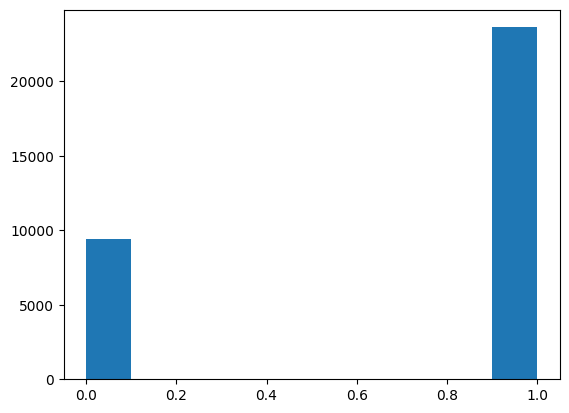

In [5]:
# target dist
plt.hist(df.PaidInFull)

In [6]:
df.PaidInFull.value_counts()

PaidInFull
1    23634
0     9394
Name: count, dtype: int64

In [7]:
predictors=df.columns
predictors

Index(['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState',
       'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist',
       'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr',
       'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross',
       'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv',
       'DisbursementGross_num', 'ChgOffPrinGr_num', 'PropPaid', 'GrAppv_num',
       'SBA_Appv_num', 'BalanceGross_num', 'NAICS_sector', 'IsFranchise',
       'NewExist_f', 'UrbanRural_f', 'PaidInFull', 'SBA_Portion',
       'RevLineCr_f', 'LowDoc_f', 'GFC_Period'],
      dtype='object')

In [ ]:
# export predictors to an excel with each predictor in a separate row
pd.DataFrame({"predictor": predictors}).to_excel("predictors.xlsx", index=False)

AttributeError: 'Index' object has no attribute 'to_excel'

In [ ]:
# LoanNr_ChkDgt (index)
# PaidInFull (target)
# NAICS (business classification)
# NAICS_sector
# Zip (zip code)
# UrbanRural (categorical)
# NewExist (categorical)
# FranchiseCode (categorical)

In [22]:
num_df = df.select_dtypes(include="number")
num_df

,LoanNr_ChkDgt,Zip,NAICS,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,DisbursementGross_num,ChgOffPrinGr_num,PropPaid,GrAppv_num,SBA_Appv_num,BalanceGross_num,NAICS_sector,PaidInFull,SBA_Portion
0,1285015002,20170,722211,2005,84,3,2,0,3,1,1,12478.0,0.0,1.000000,10000.0,5000.0,0,72,1,0.50
1,7453294006,44256,237310,2004,126,1,2,0,0,1,1,255000.0,0.0,1.000000,255000.0,191250.0,0,23,1,0.75
2,3069936008,36551,485320,2008,84,2,1,0,2,1,2,10000.0,0.0,1.000000,10000.0,5000.0,0,48,1,0.50
3,5148084007,2174,453110,2002,48,6,1,1,7,1,1,23500.0,0.0,1.000000,10000.0,5000.0,0,45,1,0.50
4,2452396010,33147,335312,2007,39,2,1,2,2,1,1,39899.0,21799.0,0.453645,25000.0,12500.0,0,33,0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33023,7261494002,97211,811121,2004,84,4,1,0,4,1,1,104213.0,0.0,1.000000,25000.0,12500.0,0,81,1,0.50
33024,1332565007,47006,722213,2005,60,1,2,0,1,1,1,24248.0,0.0,1.000000,15000.0,7500.0,0,72,1,0.50
33025,1029235010,33322,448210,2004,84,1,2,0,0,1,1,18430.0,0.0,1.000000,10000.0,5000.0,0,44,1,0.50
33026,1905465010,94591,561510,2006,54,2,1,0,2,0,1,17000.0,9000.0,0.470588,9000.0,4500.0,0,56,0,0.50


In [37]:
num_predictors=['ApprovalFY', 'Term', 'NoEmp',
        'CreateJob', 'RetainedJob' ,
       'DisbursementGross_num', 'ChgOffPrinGr_num', 'PropPaid', 'GrAppv_num',
       'SBA_Appv_num', 'BalanceGross_num', 'SBA_Portion']

In [38]:
df[num_predictors]

,ApprovalFY,Term,NoEmp,CreateJob,RetainedJob,DisbursementGross_num,ChgOffPrinGr_num,PropPaid,GrAppv_num,SBA_Appv_num,BalanceGross_num,SBA_Portion
0,2005,84,3,0,3,12478.0,0.0,1.000000,10000.0,5000.0,0,0.50
1,2004,126,1,0,0,255000.0,0.0,1.000000,255000.0,191250.0,0,0.75
2,2008,84,2,0,2,10000.0,0.0,1.000000,10000.0,5000.0,0,0.50
3,2002,48,6,1,7,23500.0,0.0,1.000000,10000.0,5000.0,0,0.50
4,2007,39,2,2,2,39899.0,21799.0,0.453645,25000.0,12500.0,0,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...
33023,2004,84,4,0,4,104213.0,0.0,1.000000,25000.0,12500.0,0,0.50
33024,2005,60,1,0,1,24248.0,0.0,1.000000,15000.0,7500.0,0,0.50
33025,2004,84,1,0,0,18430.0,0.0,1.000000,10000.0,5000.0,0,0.50
33026,2006,54,2,0,2,17000.0,9000.0,0.470588,9000.0,4500.0,0,0.50


In [40]:
df.BalanceGross_num.value_counts()

BalanceGross_num
0         33027
996262        1
Name: count, dtype: int64

array([[<Axes: title={'center': 'ApprovalFY'}>,
        <Axes: title={'center': 'Term'}>,
        <Axes: title={'center': 'NoEmp'}>],
       [<Axes: title={'center': 'CreateJob'}>,
        <Axes: title={'center': 'RetainedJob'}>,
        <Axes: title={'center': 'DisbursementGross_num'}>],
       [<Axes: title={'center': 'ChgOffPrinGr_num'}>,
        <Axes: title={'center': 'PropPaid'}>,
        <Axes: title={'center': 'GrAppv_num'}>],
       [<Axes: title={'center': 'SBA_Appv_num'}>,
        <Axes: title={'center': 'BalanceGross_num'}>,
        <Axes: title={'center': 'SBA_Portion'}>]], dtype=object)

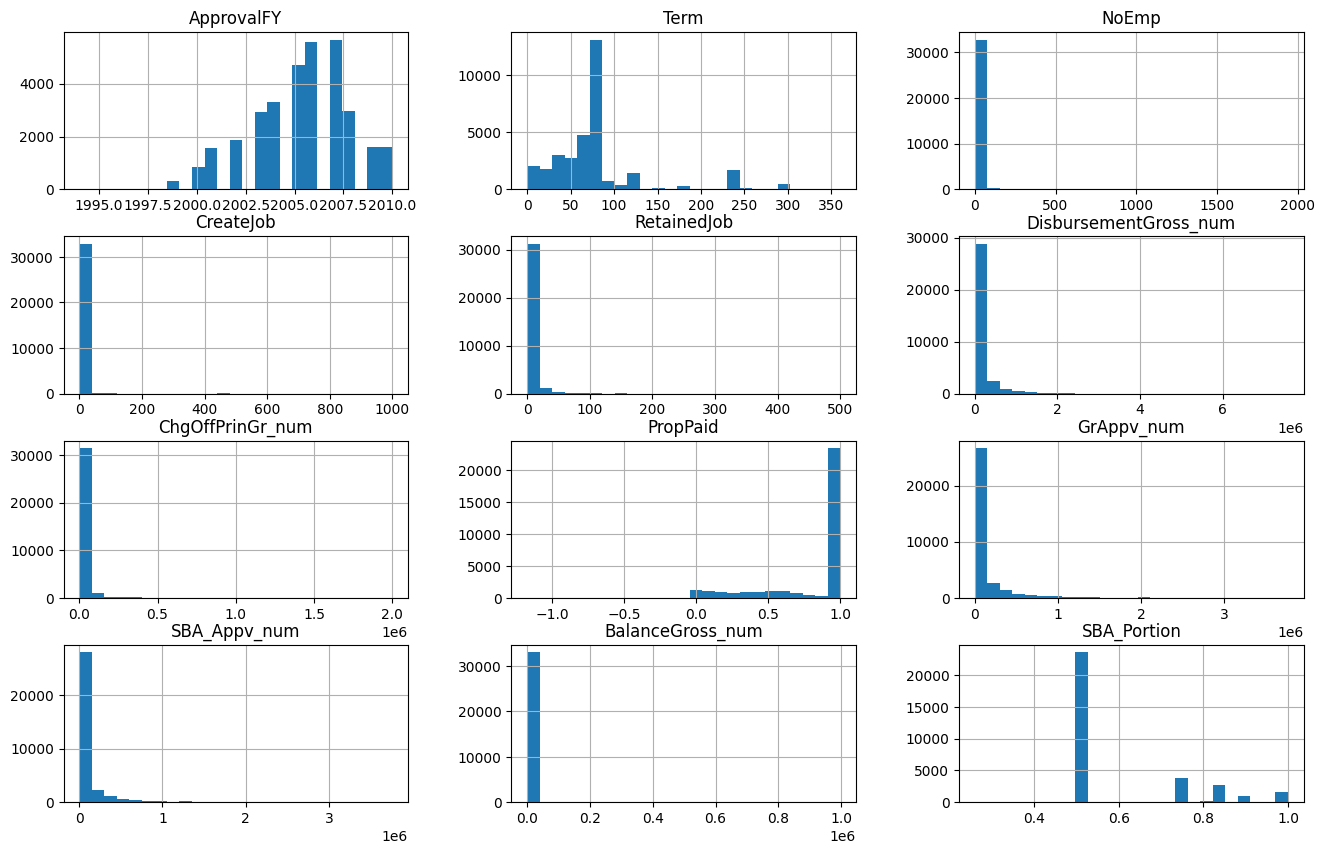

In [41]:
df[num_predictors].hist(figsize=(16, 10), bins=25)

In [51]:
# bivariate plots

# Checking Model Assumptions

In [42]:
# sus of BalanceGross_num

In [71]:
def binned_binary_plot(df, predictors, target, bins=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    
    n_cols = 4
    n_rows = (len(predictors) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    
    for i, col in enumerate(predictors):
        ax = axes[i // n_cols, i % n_cols]
        
        binned = pd.qcut(df[col], bins, duplicates='drop')
        
        grouped = df.groupby(binned).agg(
            x_median=(col, "median"),
            event_rate=(target, "mean")  # THIS is key
        ).reset_index(drop=True)
        
        ax.plot(grouped["x_median"], grouped["event_rate"], marker='o')
        ax.set_title(col)
        ax.set_ylabel("P(Y=1)")
        ax.set_xlabel("median binned X")
    
    for j in range(i+1, n_rows*n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
    
    plt.tight_layout()
    plt.show()

C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\1878342817.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned).agg(
C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\1878342817.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned).agg(
C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\1878342817.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.g

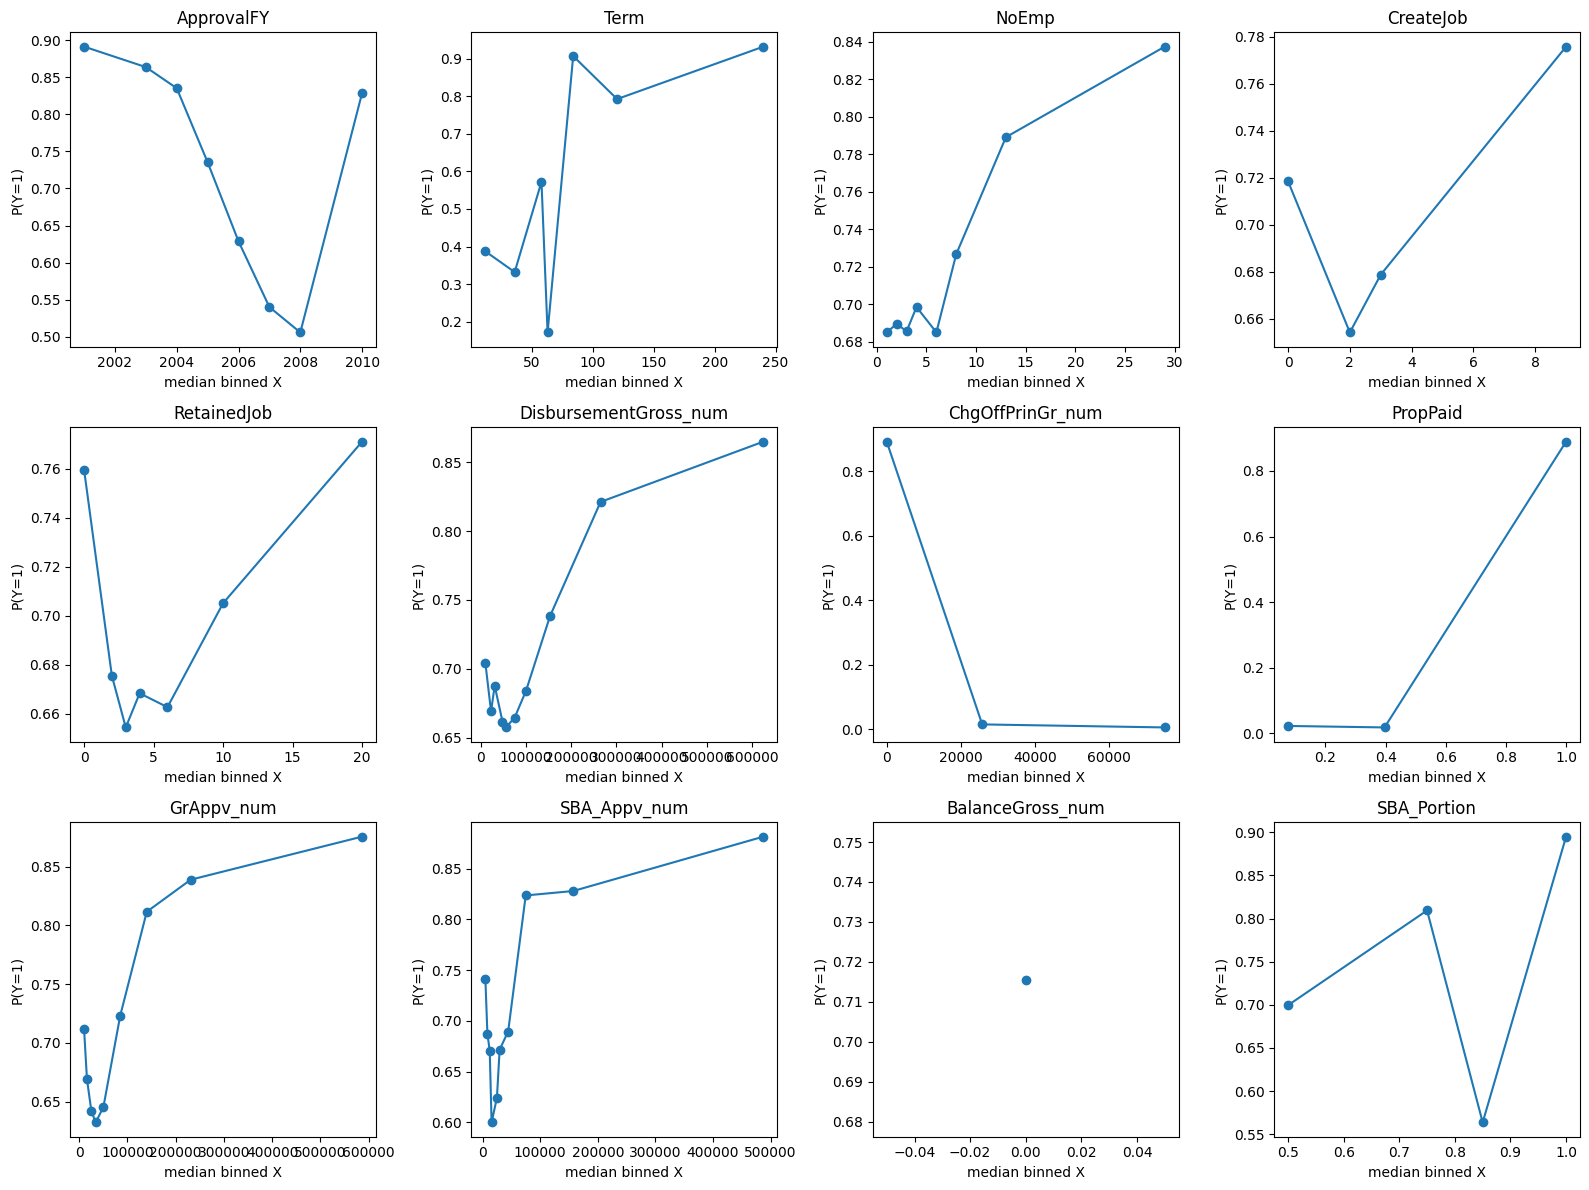

In [72]:
binned_binary_plot(df, num_predictors, target="PaidInFull", bins=10)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def binned_logit_plot(df, predictors, target, bins=10, eps=1e-5):
    
    n_cols = 4
    n_rows = (len(predictors) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    
    for i, col in enumerate(predictors):
        ax = axes[i // n_cols, i % n_cols]
        
        # Bin predictor
        binned = pd.qcut(df[col], bins, duplicates='drop')
        
        grouped = df.groupby(binned).agg(
            x_median=(col, "median"),
            p_event=(target, "mean"),
            n_obs=(target, "count")
        ).reset_index(drop=True)
        
        # Clip probabilities to avoid log(0) or division by 0
        p = np.clip(grouped["p_event"], eps, 1 - eps)
        
        # Compute logit
        grouped["logit"] = np.log(p / (1 - p))
        
        # Plot
        ax.plot(grouped["x_median"], grouped["logit"], marker='o')
        ax.set_title(col)
        ax.set_xlabel("x (median in bin)")
        ax.set_ylabel("logit(P(Y=1))")
        
        # Optional: add linear fit line
        if len(grouped) > 1:
            z = np.polyfit(grouped["x_median"], grouped["logit"], 1)
            p_line = np.poly1d(z)
            ax.plot(grouped["x_median"], p_line(grouped["x_median"]), linestyle='--')
    
    # Remove unused subplots
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
    
    plt.tight_layout()
    plt.show()

C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\2297251447.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned).agg(
C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\2297251447.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(binned).agg(
C:\Users\alexa\AppData\Local\Temp\ipykernel_16340\2297251447.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.g

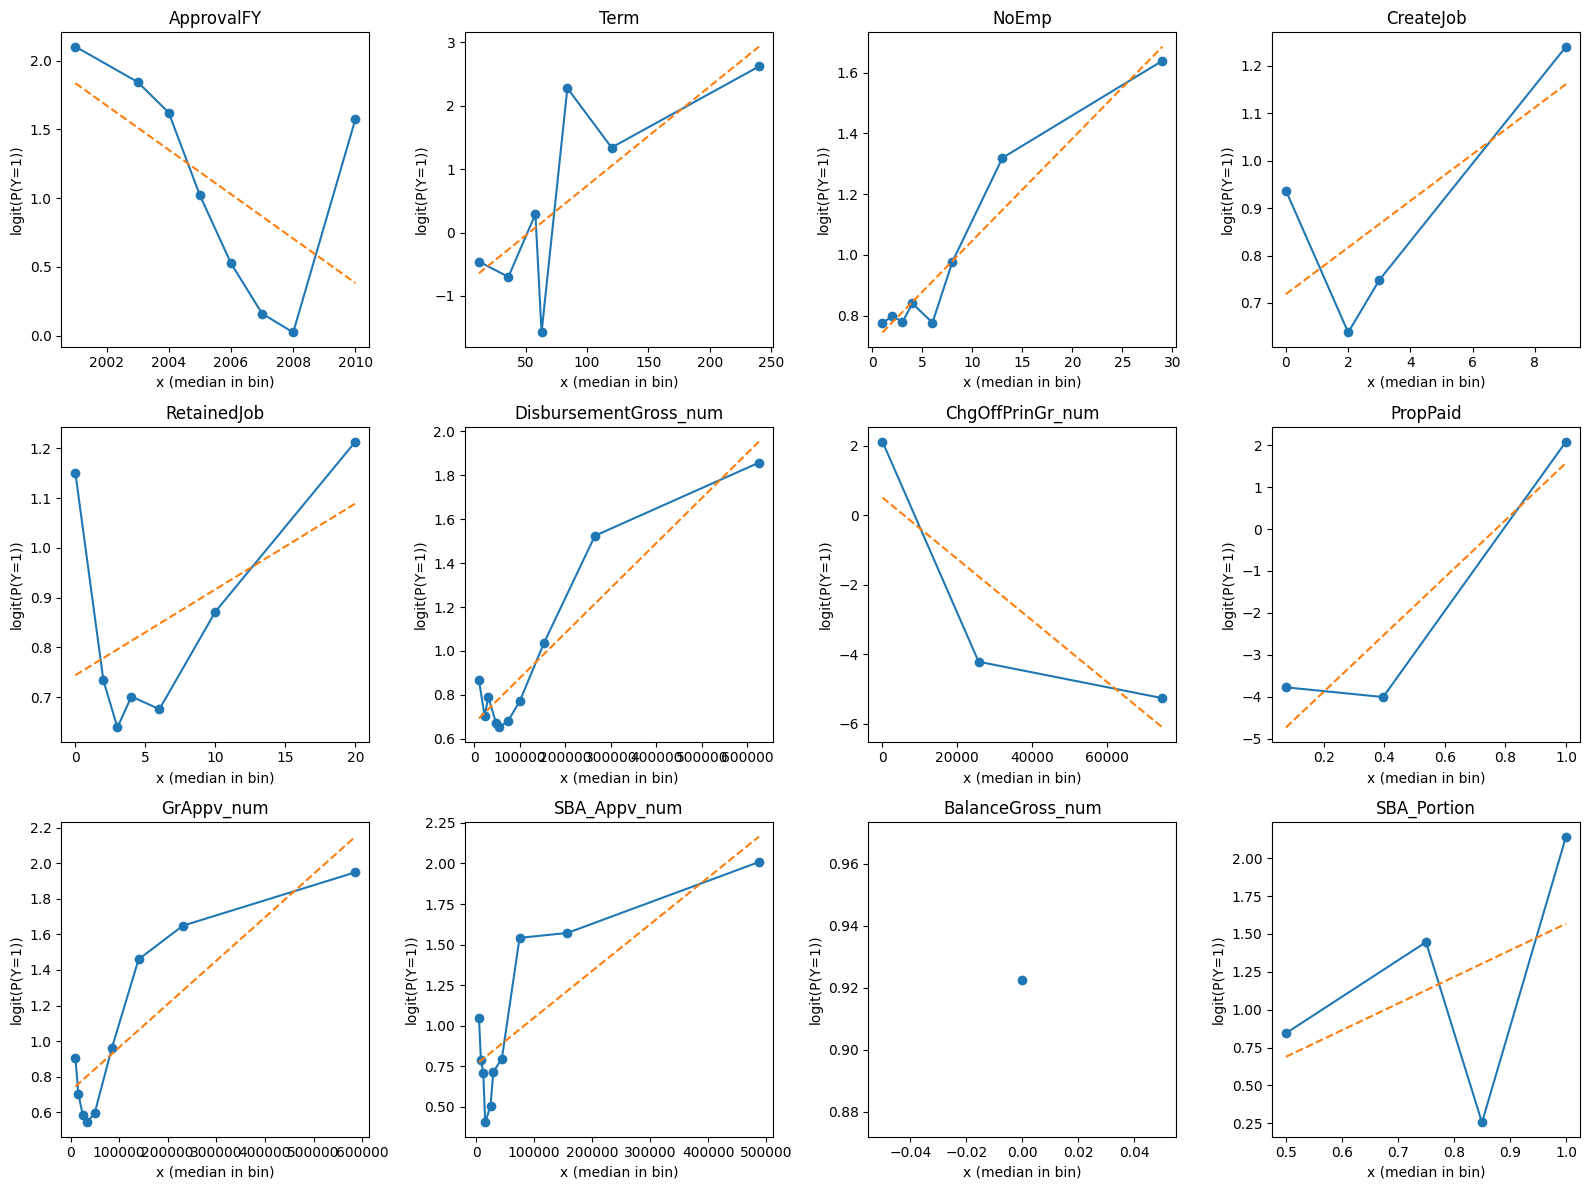

In [75]:
binned_logit_plot(df, num_predictors, target="PaidInFull")

## WOE/IV Check

In [ ]:
# https://www.listendata.com/2015/03/weight-of-evidence-woe-and-information.html

In [52]:
def iv_woe(data, target, bins=10, show_woe=False):
    
    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()
    
    #Extract Column Names
    cols = data.columns
    
    #Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (data[ivars].dtype.kind in 'bifc') and (len(np.unique(data[ivars]))>10):
            binned_x = pd.qcut(data[ivars], bins,  duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': data[target]})
        else:
            d0 = pd.DataFrame({'x': data[ivars], 'y': data[target]})
        d0 = d0.astype({"x": str})
        d = d0.groupby("x", as_index=False, dropna=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']
        d['% of Events'] = np.maximum(d['Events'], 0.5) / d['Events'].sum()
        d['Non-Events'] = d['N'] - d['Events']
        d['% of Non-Events'] = np.maximum(d['Non-Events'], 0.5) / d['Non-Events'].sum()
        d['WoE'] = np.log(d['% of Non-Events']/d['% of Events'])
        d['IV'] = d['WoE'] * (d['% of Non-Events']-d['% of Events'])
        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(),6)))
        temp =pd.DataFrame({"Variable" : [ivars], "IV" : [d['IV'].sum()]}, columns = ["Variable", "IV"])
        newDF=pd.concat([newDF,temp], axis=0)
        woeDF=pd.concat([woeDF,d], axis=0)

        #Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF

In [61]:
iv, woe = iv_woe(data = df, target = 'PaidInFull', bins=10, show_woe = True)

Information value of LoanNr_ChkDgt is 0.455462
        Variable                          Cutoff     N  Events  % of Events  \
0  LoanNr_ChkDgt  (1000446005.999, 1407024008.5]  3303    2429     0.102776   
1  LoanNr_ChkDgt    (1407024008.5, 1824409002.2]  3303    2140     0.090548   
2  LoanNr_ChkDgt    (1824409002.2, 2232534102.9]  3303    1937     0.081958   
3  LoanNr_ChkDgt    (2232534102.9, 2616993005.0]  3302    1816     0.076838   
4  LoanNr_ChkDgt    (2616993005.0, 3053064501.5]  3303    1629     0.068926   
5  LoanNr_ChkDgt    (3053064501.5, 3679943002.8]  3303    2440     0.103241   
6  LoanNr_ChkDgt    (3679943002.8, 4784542009.4]  3302    2893     0.122408   
7  LoanNr_ChkDgt    (4784542009.4, 6176436003.6]  3303    2910     0.123128   
8  LoanNr_ChkDgt    (6176436003.6, 7343714005.8]  3303    2828     0.119658   
9  LoanNr_ChkDgt    (7343714005.8, 9897994004.0]  3303    2612     0.110519   

   Non-Events  % of Non-Events       WoE        IV  
0         874         0.093038

In [56]:
woe

,Variable,Cutoff,N,Events,% of Events,Non-Events,% of Non-Events,WoE,IV
0,LoanNr_ChkDgt,"(1000446005.999, 1407024008.5]",3303,2429,0.102776,874,0.093038,-0.099539,0.000969
1,LoanNr_ChkDgt,"(1407024008.5, 1824409002.2]",3303,2140,0.090548,1163,0.123802,0.312812,0.010403
2,LoanNr_ChkDgt,"(1824409002.2, 2232534102.9]",3303,1937,0.081958,1366,0.145412,0.573362,0.036382
3,LoanNr_ChkDgt,"(2232534102.9, 2616993005.0]",3302,1816,0.076838,1486,0.158186,0.722067,0.058738
4,LoanNr_ChkDgt,"(2616993005.0, 3053064501.5]",3303,1629,0.068926,1674,0.178199,0.949865,0.103794
...,...,...,...,...,...,...,...,...,...
1,RevLineCr_f,Yes,17885,12932,0.547178,4953,0.527251,-0.037096,0.000739
0,LowDoc_f,No,32892,23521,0.995219,9371,0.997552,0.002341,0.000005
1,LowDoc_f,Yes,136,113,0.004781,23,0.002448,-0.669278,0.001561
0,GFC_Period,GFC,6157,4146,0.175425,2011,0.214073,0.199103,0.007695


In [59]:
iv.sort_values(by="IV",ascending=False)

,Variable,IV
0,MIS_Status,20.603811
0,ChgOffDate,13.000477
0,ChgOffPrinGr,11.517799
0,ChgOffPrinGr_num,4.754616
0,PropPaid,4.084815
0,Term,1.475517
0,Name,1.364495
0,DisbursementGross,0.851738
0,ApprovalDate,0.826200
0,City,0.720704


## Iterative VIF checking 


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [44]:
X = df[num_predictors].copy()

In [45]:
X = add_constant(X)

In [46]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

In [47]:
print(vif_data)

                  feature            VIF
0                   const  690457.632809
1              ApprovalFY       1.087179
2                    Term       1.926136
3                   NoEmp       1.477025
4               CreateJob       1.039424
5             RetainedJob       1.420424
6   DisbursementGross_num       9.092245
7        ChgOffPrinGr_num       1.411129
8                PropPaid       1.429629
9              GrAppv_num      53.182518
10           SBA_Appv_num      41.885144
11       BalanceGross_num       1.000713
12            SBA_Portion       1.873677


In [48]:
# iterative
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(X):
    X_const = add_constant(X)
    vif = pd.DataFrame()
    vif["feature"] = X_const.columns
    vif["VIF"] = [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
    return vif[vif["feature"] != "const"]  # drop intercept


def vif_elimination(df, features, threshold=10.0, verbose=True):
    X = df[features].copy()
    
    while True:
        vif = calculate_vif(X)
        max_vif = vif["VIF"].max()
        max_feature = vif.loc[vif["VIF"].idxmax(), "feature"]
        
        if max_vif <= threshold:
            break
        
        if verbose:
            print(f"Removing '{max_feature}' with VIF = {max_vif:.2f}")
        
        X = X.drop(columns=[max_feature])
    
    return X.columns.tolist(), vif

In [49]:
selected_features, final_vif = vif_elimination(df, num_predictors)

print("Final features:", selected_features)
print(final_vif)

Removing 'GrAppv_num' with VIF = 53.18
Final features: ['ApprovalFY', 'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross_num', 'ChgOffPrinGr_num', 'PropPaid', 'SBA_Appv_num', 'BalanceGross_num', 'SBA_Portion']
                  feature       VIF
1              ApprovalFY  1.087094
2                    Term  1.925816
3                   NoEmp  1.473352
4               CreateJob  1.032917
5             RetainedJob  1.413055
6   DisbursementGross_num  6.434644
7        ChgOffPrinGr_num  1.367176
8                PropPaid  1.429458
9            SBA_Appv_num  7.959817
10       BalanceGross_num  1.000563
11            SBA_Portion  1.737699
